# GBM p53 ODE Model

**Run order:**
1. `GBM_p53_preproc.R` → generates `GBM_patient_p53genes.csv`
2. This notebook → generates p53 activity outputs for TCGA-GBM patients
3. `GBM_Analysis.R` (Question 1 block) → uses outputs to answer the brief's Q3

**Outputs:**
- `GBM_p53s15DR_patients.csv` — p53-Ser15 phosphorylation per patient per DDR level
- `GBM_p53s46DR_patients.csv` — p53-Ser46 phosphorylation per patient per DDR level

**DDR grid:** 10 levels via `np.linspace(0.01, 1, num=10)` → [0.01, 0.12, 0.23, 0.34, 0.45, 0.56, 0.67, 0.78, 0.89, 1.00]
This produces 20 candidate features per patient (10 DDR levels × 2 phosphosites: Ser15, Ser46).

*(Note: the original version of this notebook also ran the ODE model for DepMap GBM cell lines. That block has been removed here — it isn't needed for Q1 or Q3.)*

In [15]:
import numpy as np
import pandas as pd
import scipy.integrate
import pylab as plt
import os

directory = os.getcwd()
print('Working directory:', directory)

Working directory: /Users/hanna/Documents/Claude/Projects/AI for Personalised Medicine


In [16]:
# Load pre-fitted model parameters from the example archive
est_params = pd.read_csv("example_modelling_survival_arch/p53_parameters_summaryTable.txt",
                         sep=' ', decimal=".", index_col=False)
est_params = est_params.set_index('objFun')
print('Parameter sets loaded:', len(est_params))
est_params.head()

Parameter sets loaded: 100


,rSeed,kpatm_dox,kpatm_rad,jpatm_dox,jpatm_rad,kdpatm_dox,kdpatm_rad,jdpatm_dox,jdpatm_rad,kpchk2,...,jsmdm21,kswip11,jswip11,kdp53,kdp53a,jup53,jup53s,juhipk2,sf_s15,sf_s46
objFun,,,,,,,,,,,,,,,,,,,,,
6.942752,98,1.192694,0.714128,0.999984,0.010015,0.378553,4.287005,0.999883,0.022713,39.995208,...,0.101065,0.681054,0.203931,2.000115,0.100006,0.099334,9.936632,0.040073,1.020440,1.999023
6.950910,8,1.198872,0.758123,0.999844,0.010000,0.388248,4.591436,0.999995,0.024373,39.863482,...,0.100215,0.733839,0.227036,2.000083,0.100023,0.099570,9.912894,0.057912,1.020877,1.999747
6.953756,86,1.193425,0.685960,0.999851,0.010012,0.373503,4.163046,0.999983,0.023883,39.934227,...,0.100296,0.706250,0.204089,2.000086,0.100024,0.099628,9.999998,0.015715,1.020742,1.999993
6.953936,28,1.191406,0.687003,0.999280,0.010037,0.403160,4.130286,0.999697,0.024111,39.966909,...,0.102827,0.740777,0.234306,2.000356,0.100010,0.099718,9.995392,0.001011,1.021418,1.999984
6.954126,38,1.195641,0.721971,0.999962,0.010000,0.389960,4.353016,0.999689,0.023856,39.967650,...,0.100072,0.805132,0.247038,2.000601,0.100022,0.098702,9.998095,0.001002,1.022373,1.999832


In [17]:
# Fixed kinetic parameters
# Dosage placeholder
DDR = 1

hcmdm21  = 2
hcwip11  = 2
kdhipk2  = 1.5    # HIPK2 basal degradation, half-life ~27 min
kdp53m   = 0.077  # p53 mRNA half-life ~9 h
kdwip1m  = 0.66   # WIP1 mRNA degradation
kdwip1   = 2      # WIP1 protein degradation, half-life ~20 min
kdmdm2m  = 0.7    # MDM2 mRNA degradation
kdmdm2   = 2      # MDM2 protein degradation, half-life ~20 min
kuhipk2  = 0.17   # SIAH1-induced HIPK2 degradation
hcdeg    = 2
kalg     = 0.1

# Reference initial conditions
p_p53i_0  = 0.1
p_MDM2m_0 = 0.103
p_p53m_0  = 0.1
WIP1m_0   = 0.0594
WIP1_0    = 0.0277
MDM2_0    = 1
p_ATM_0   = 1
p_SIAH_0  = 1
p_HIPK2_0 = 0.018
p_CHK2    = 1
icZero    = 0

# Derived baseline parameters (algebraic constraints from ICs)
i_selectedrun = 0

ksp530   = p_p53m_0 * kdp53m
kpsmdm2  = MDM2_0 * kdmdm2 / p_MDM2m_0
h_MDM2_0 = (MDM2_0**hcdeg) / (MDM2_0**hcdeg + est_params.iloc[i_selectedrun]['jup53']**hcdeg)
kpsp53   = est_params.iloc[i_selectedrun]['kdp53'] * p_p53i_0 / p_p53m_0 * h_MDM2_0
h_p53i_0 = ((kalg*p_p53i_0)**hcmdm21) / (est_params.iloc[i_selectedrun]['jsmdm21']**hcmdm21 + (kalg*p_p53i_0)**hcmdm21)
ksmdm20  = kdmdm2m * p_MDM2m_0 - est_params.iloc[i_selectedrun]['ksmdm21'] * h_p53i_0
kswip10  = kdwip1m * WIP1m_0
kpswip1  = kdwip1 * WIP1_0 / WIP1m_0
p_kshipk2 = kdhipk2 * p_HIPK2_0 + kuhipk2 * p_SIAH_0 * p_HIPK2_0 / (est_params.iloc[i_selectedrun]['juhipk2'] + p_HIPK2_0)

x0 = [p_ATM_0, icZero, p_p53m_0, p_p53i_0, icZero, icZero,
       p_SIAH_0, icZero, p_HIPK2_0, WIP1m_0, WIP1_0,
       p_CHK2, icZero, p_MDM2m_0, MDM2_0]

print('Baseline parameters computed.')

Baseline parameters computed.


In [18]:
# Patient/cell-line-specific parameter function
# Takes a row from the input CSV (gene expression as relative values) and sets the global initial condition vector x0 accordingly.

def setpatientparams(sample_row):
    global kpsmdm2, kpsp53, kpswip1, x0
    global kshipk2, kswip10, ksmdm20, ksp530

    # Reset baseline
    ksp530  = p_p53m_0 * kdp53m
    kpsmdm2 = MDM2_0 * kdmdm2 / p_MDM2m_0
    h_MDM2_0_ = (MDM2_0**hcdeg) / (MDM2_0**hcdeg + est_params.iloc[i_selectedrun]['jup53']**hcdeg)
    kpsp53  = est_params.iloc[i_selectedrun]['kdp53'] * p_p53i_0 / p_p53m_0 * h_MDM2_0_
    h_p53i_0_ = ((kalg*p_p53i_0)**hcmdm21) / (est_params.iloc[i_selectedrun]['jsmdm21']**hcmdm21 + (kalg*p_p53i_0)**hcmdm21)
    ksmdm20 = kdmdm2m * p_MDM2m_0 - est_params.iloc[i_selectedrun]['ksmdm21'] * h_p53i_0_
    kswip10 = kdwip1m * WIP1m_0
    kpswip1 = kdwip1 * WIP1_0 / WIP1m_0
    kshipk2 = kdhipk2 * p_HIPK2_0 + kuhipk2 * p_SIAH_0 * p_HIPK2_0 / (est_params.iloc[i_selectedrun]['juhipk2'] + p_HIPK2_0)

    # Patient/cell-line-specific overrides
    ATM_0   = sample_row['ATM']   * p_ATM_0
    CHK2_0  = sample_row['CHEK2'] * p_CHK2

    p53m_    = sample_row['TP53'] * p_p53m_0
    ksp530   = p53m_ * kdp53m

    MDM2m_   = sample_row['MDM2'] * p_MDM2m_0
    MDM2_    = MDM2m_ * kpsmdm2 / kdmdm2
    h_MDM2_  = (MDM2_**hcdeg) / (MDM2_**hcdeg + est_params.iloc[i_selectedrun]['jup53']**hcdeg)
    p53i_    = p53m_ * kpsp53 / est_params.iloc[i_selectedrun]['kdp53'] / max(h_MDM2_, 1e-9)
    h_p53i_  = ((kalg*p53i_)**hcmdm21) / (est_params.iloc[i_selectedrun]['jsmdm21']**hcmdm21 + (kalg*p53i_)**hcmdm21)
    ksmdm20  = MDM2m_ * kdmdm2m - est_params.iloc[i_selectedrun]['ksmdm21'] * h_p53i_

    WIP1m_   = sample_row['PPM1D'] * WIP1m_0
    kswip10  = WIP1m_ * kdwip1m
    WIP1_    = WIP1m_ * kpswip1 / kdwip1

    SIAH_0_  = 0.5 * (sample_row['SIAH1'] + sample_row['WSB1']) * p_SIAH_0

    kshipk2  = sample_row['HIPK2'] * p_kshipk2
    disc     = (SIAH_0_**2 * kuhipk2**2
                + 2*SIAH_0_*est_params.iloc[i_selectedrun]['juhipk2']*kdhipk2*kuhipk2
                - 2*SIAH_0_*kshipk2*kuhipk2
                + est_params.iloc[i_selectedrun]['juhipk2']**2 * kdhipk2**2
                + 2*est_params.iloc[i_selectedrun]['juhipk2']*kdhipk2*kshipk2
                + kshipk2**2)
    HIPK2_  = (kshipk2 - SIAH_0_*kuhipk2
               - est_params.iloc[i_selectedrun]['juhipk2']*kdhipk2
               + max(disc, 0)**0.5) / (2*kdhipk2)

    if ksmdm20 < 0:
        ksmdm20 = 1e-9
    if HIPK2_ < 0:
        HIPK2_ = 1e-9

    x0 = [ATM_0, icZero, p_p53m_0, p_p53i_0, icZero, icZero,
           SIAH_0_, icZero, p_HIPK2_0, WIP1m_0, WIP1_0,
           p_CHK2, icZero, p_MDM2m_0, MDM2_0]

print('setpatientparams() defined.')

setpatientparams() defined.


In [19]:
# ODE system

def f(x, t, DDR):
    WIP1a   = 1
    kpatm   = est_params.iloc[i_selectedrun]['kpatm_dox']
    jpatm   = est_params.iloc[i_selectedrun]['jpatm_dox']
    kdpatm  = est_params.iloc[i_selectedrun]['kdpatm_dox']
    jdpatm  = est_params.iloc[i_selectedrun]['jdpatm_dox']

    ATM, ATMp, p53m, p53i, p53s15, p53s46 = x[0], x[1], x[2], x[3], x[4], x[5]
    SIAH1, SIAH1p, HIPK2, WIP1m, WIP1     = x[6], x[7], x[8], x[9], x[10]
    CHK2, CHK2p, MDM2m, MDM2              = x[11], x[12], x[13], x[14]

    ku = np.heaviside(t, 1)

    v1  = kpatm * ATM * DDR * ku / (jpatm + ATM)
    v2  = kdpatm * WIP1a * ATMp / (jdpatm + ATMp)
    v3  = est_params.iloc[i_selectedrun]['kpchk2'] * ATMp * CHK2 / (est_params.iloc[i_selectedrun]['jpchk2'] + CHK2)
    v4  = est_params.iloc[i_selectedrun]['kdpchk2'] * WIP1 * CHK2p / (est_params.iloc[i_selectedrun]['jdpchk2'] + CHK2p)
    v5  = est_params.iloc[i_selectedrun]['kpp53_CHK2'] * CHK2p * p53i / (est_params.iloc[i_selectedrun]['jpp53_CHK2'] + p53i)
    v6  = est_params.iloc[i_selectedrun]['kpp53_ATM'] * ATMp * p53i / (est_params.iloc[i_selectedrun]['jpp53_ATM'] + p53i)
    v7  = est_params.iloc[i_selectedrun]['kdpp53a'] * WIP1 * p53s15 / (est_params.iloc[i_selectedrun]['jdpp53a'] + p53s15)
    v8  = est_params.iloc[i_selectedrun]['kpp53a'] * HIPK2 * p53s15 / (est_params.iloc[i_selectedrun]['jpp53a'] + p53s15)
    v9  = est_params.iloc[i_selectedrun]['kdpp53k'] * p53s46 / (est_params.iloc[i_selectedrun]['jdpp53k'] + p53s46)
    v10 = est_params.iloc[i_selectedrun]['kpsiah1'] * ATMp * SIAH1 / (est_params.iloc[i_selectedrun]['jpsiah1'] + SIAH1)
    v11 = est_params.iloc[i_selectedrun]['kdpsiah1'] * SIAH1p / (est_params.iloc[i_selectedrun]['jdpsiah1'] + SIAH1p)

    p53alg   = kalg * p53i + p53s15 + p53s46
    p53s15tot = p53s15 + p53s46

    v12 = ksp530
    v13 = ksmdm20
    v14 = est_params.iloc[i_selectedrun]['ksmdm21'] * p53alg**hcmdm21 / (est_params.iloc[i_selectedrun]['jsmdm21']**hcmdm21 + p53alg**hcmdm21)
    v15 = kswip10
    v16 = est_params.iloc[i_selectedrun]['kswip11'] * p53s15tot**hcwip11 / (est_params.iloc[i_selectedrun]['jswip11']**hcwip11 + p53s15tot**hcwip11)

    v21 = kpsp53 * p53m
    v22 = kshipk2
    v23 = kpswip1 * WIP1m
    v24 = kpsmdm2 * MDM2m

    v25 = est_params.iloc[i_selectedrun]['kdp53']  * p53i   * MDM2**hcdeg / (MDM2**hcdeg + est_params.iloc[i_selectedrun]['jup53']**hcdeg)
    v26 = est_params.iloc[i_selectedrun]['kdp53a'] * p53s15 * MDM2**hcdeg / (MDM2**hcdeg + est_params.iloc[i_selectedrun]['jup53s']**hcdeg)
    v27 = est_params.iloc[i_selectedrun]['kdp53a'] * p53s46 * MDM2**hcdeg / (MDM2**hcdeg + est_params.iloc[i_selectedrun]['jup53s']**hcdeg)
    v28 = kdhipk2 * HIPK2
    v29 = kdp53m * p53m
    v30 = kdwip1m * WIP1m
    v31 = kdwip1 * WIP1
    v32 = kdmdm2m * MDM2m
    v33 = kdmdm2 * MDM2
    v36 = kuhipk2 * SIAH1 * HIPK2 / (est_params.iloc[i_selectedrun]['juhipk2'] + HIPK2)

    return [
        -v1+v2, v1-v2,          # ATM, ATMp
        v12-v29,                # p53m
        -v5-v6+v7+v21-v25,     # p53i
        v5+v6-v7-v8+v9-v26,    # p53s15
        v8-v9-v27,              # p53s46
        -v10+v11, v10-v11,     # SIAH1, SIAH1p
        v22-v28-v36,            # HIPK2
        v15+v16-v30, v23-v31,  # WIP1m, WIP1
        -v3+v4, v3-v4,         # CHK2, CHK2p
        v13+v14-v32, v24-v33   # MDM2m, MDM2
    ]

print('ODE system f() defined.')

ODE system f() defined.


In [20]:
# Simulation function: run ODE for a set of samples

DDRvec       = np.linspace(0.01, 1, num=10)
Tfinish      = 50
numberOfPoints = 10
tspan        = np.linspace(0, Tfinish, num=numberOfPoints)

def run_ode_for_cohort(params_df, label='cohort'):
    col_names = ['DDR_' + '{:.3f}'.format(d) for d in DDRvec]
    p53s15_df = pd.DataFrame(columns=col_names)
    p53s46_df = pd.DataFrame(columns=col_names)

    for i in range(len(params_df)):
        row = params_df.iloc[i]
        setpatientparams(row)
        s15_row, s46_row = [], []
        for DDRval in DDRvec:
            sol = scipy.integrate.odeint(f, x0, tspan, args=(DDRval,))
            s15_row.append(sol[-1, 4])  # p53s15 at final time
            s46_row.append(sol[-1, 5])  # p53s46 at final time
        p53s15_df.loc[i] = s15_row
        p53s46_df.loc[i] = s46_row
        if (i + 1) % 10 == 0 or i == len(params_df) - 1:
            print(f'  {label}: {i+1}/{len(params_df)} done')

    # Attach identifiers
    p53s15_df['SAMPLE_ID']  = params_df['SAMPLE_ID'].values
    p53s15_df['PATIENT_ID'] = params_df['PATIENT_ID'].values
    p53s46_df['SAMPLE_ID']  = params_df['SAMPLE_ID'].values
    p53s46_df['PATIENT_ID'] = params_df['PATIENT_ID'].values

    return p53s15_df, p53s46_df

print('run_ode_for_cohort() defined.')

run_ode_for_cohort() defined.


In [21]:
# Run ODE for TCGA-GBM patients

patient_params = pd.read_csv('GBM_patient_p53genes.csv')
print(f'TCGA-GBM patients: {len(patient_params)}')
patient_params.head()

TCGA-GBM patients: 159


,ATM,CHEK2,HIPK2,MDM2,PPM1D,SIAH1,TP53,WSB1,SAMPLE_ID,PATIENT_ID
0,1.583476,0.650229,1.766865,0.534487,1.884721,0.124400,1.150919,1.038665,TCGA-02-0047-01,TCGA-02-0047
1,0.566512,2.265379,1.023611,0.169068,0.009149,0.369759,0.008950,0.612673,TCGA-02-0055-01,TCGA-02-0055
2,0.201439,2.588819,0.282464,0.814475,2.915919,3.281928,2.566677,0.170415,TCGA-02-2483-01,TCGA-02-2483
3,0.958888,1.555599,0.995676,0.149851,1.579323,1.954272,1.881263,0.852716,TCGA-02-2485-01,TCGA-02-2485
4,0.286817,0.009305,0.661372,1.024765,0.749771,0.009054,0.265466,0.700393,TCGA-02-2486-01,TCGA-02-2486


Running p53 ODE for TCGA-GBM patients …
  patients: 10/159 done
  patients: 20/159 done
  patients: 30/159 done
  patients: 40/159 done
  patients: 50/159 done
  patients: 60/159 done
  patients: 70/159 done
  patients: 80/159 done
  patients: 90/159 done
  patients: 100/159 done
  patients: 110/159 done
  patients: 120/159 done
  patients: 130/159 done
  patients: 140/159 done
  patients: 150/159 done
  patients: 159/159 done
Saved: GBM_p53s15DR_patients.csv and GBM_p53s46DR_patients.csv


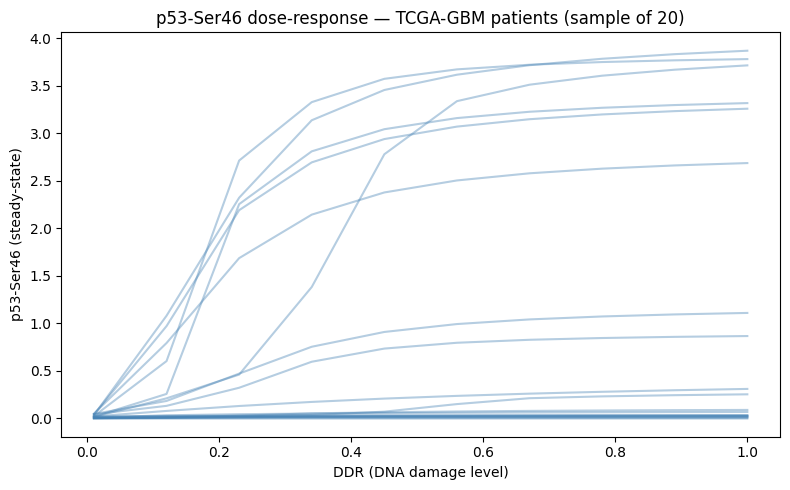

In [22]:
print('Running p53 ODE for TCGA-GBM patients …')
p53s15_patients, p53s46_patients = run_ode_for_cohort(patient_params, label='patients')

p53s15_patients.to_csv('GBM_p53s15DR_patients.csv', index=False)
p53s46_patients.to_csv('GBM_p53s46DR_patients.csv', index=False)
print('Saved: GBM_p53s15DR_patients.csv and GBM_p53s46DR_patients.csv')

# Quick visualisation: p53s46 response curves for a subset of patients
ddr_cols = ['DDR_' + '{:.3f}'.format(d) for d in DDRvec]
plt.figure(figsize=(8, 5))
for i in range(min(20, len(p53s46_patients))):
    plt.plot(DDRvec, p53s46_patients[ddr_cols].iloc[i].astype(float), alpha=0.4, color='steelblue')
plt.xlabel('DDR (DNA damage level)')
plt.ylabel('p53-Ser46 (steady-state)')
plt.title('p53-Ser46 dose-response — TCGA-GBM patients (sample of 20)')
plt.tight_layout()
plt.show()